# Pipeline 5: MEHTC + LoRA-GRPO Fine-tuned XLM-RoBERTa

### 1. Project Overview & Purpose
This notebook implements **Pipeline 5**, the flagship experiment among the six comparative studies defined in the Final Year Project (FYP): "NLP-based AI Platform for Parliament Proceedings Analysis to Enhance Governmental Transparency and Civic Engagement". The primary objective is to establish the "Upper Bound" of performance by integrating a Large Language Model (LLM) specifically fine-tuned on parliamentary discourse into the MEHTC framework. This experiment validates the impact of domain adaptation and reinforcement learning (GRPO) in optimizing the embedding space for bilingual (Malay-English) political discourse.

### 2. Technical Methodology
#### 2.1 Data Configuration
**Input:**
CPATF-preprocessed segments from the hansard_segmented500 collection.
**Sampling:** 
Stratified random sample (~20,000 segments) matched against session_range.xlsx.Temporal Scope: Longitudinal alignment across 12 distinct legislative eras (1959–2020+).

#### 2.2 Core Model: XLM-RoBERTa fine-tuned via LoRA (Parameter-Efficient Fine-Tuning) and GRPO (Group Relative Policy Optimization) reinforcement learning.
**Similarity Equation:**
$$sim(d_i, d_j) = \alpha \cdot \cos(\mathbf{v}_{tfidf,i}, \mathbf{v}_{tfidf,j}) + \beta \cdot \cos(\mathbf{e}_{ft,i}, \mathbf{e}_{ft,j}) + \gamma \cdot Jaccard_{weighted}(E_i, E_j)$$
**Clustering Algorithm:** Agglomerative Clustering.

#### 2.3 Computational EnvironmentHardware: NVIDIA RTX A6000 (Ampere, 48 GB VRAM).Optimization: CUDA-accelerated fine-tuning and high-dimensional embedding computation.


### 3. Key Findings & Metrics
#### 3.1 Quantitative Results
**Silhouette Score :** 0.0247
**C_V Coherence**    : 0.3659
**NPMI Coherence**   : -0.0080
**Topic Diversity**  : 0.5650


### 4. Outputs & Deliverables
Results Log: `results/pipeline5_results.json`
Model Bundle: `model/mehtc_lora_grpo_finetuned_model.pkl`
Visualizations: Interactive network graphs and longitudinal trend dashboard datasets.

### Imports and Setup

In [33]:
import os
import json
import pymongo
from pathlib import Path
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForMaskedLM, DataCollatorForLanguageModeling, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset
import torch
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from collections import Counter
import numpy as np
import networkx as nx
from pyvis.network import Network
from statsmodels.tsa.arima.model import ARIMA
import pickle
from datetime import datetime
import torch.nn as nn
from scipy.sparse import load_npz
import matplotlib.pyplot as plt
import pandas as pd

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Load env and MongoDB
project_root = Path.cwd().parents[0] if 'parents' in dir(Path.cwd()) else Path.cwd()
backend_env_path = project_root / "3_app_system" / "backend" / ".env"
load_dotenv(backend_env_path)

client = pymongo.MongoClient(os.getenv("MONGO_URI"))
db = client["MyParliament"]

project_root = Path.cwd().parents[0] if 'parents' in dir(Path.cwd()) else Path.cwd()
load_dotenv(project_root / "3_app_system" / "backend" / ".env")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Load Data

In [2]:
load_dir = Path("shared_data")
results_dir = Path("results")
model_dir = Path("model")

# Load CPATF cleaned texts + entities
with open(load_dir / "shared_sample_data.pkl", "rb") as f:
    shared = pickle.load(f)
cleaned_texts = shared["cleaned_texts"]
entities_list = shared["entities_list"]

# Load TF-IDF matrix
tfidf_matrix = load_npz(load_dir / "tfidf_matrix.npz")

# Load Pipeline 4 results
with open(model_dir / "mehtc_xlm_zeroshot_model.pkl", "rb") as f:
    p4_bundle = pickle.load(f)
pseudo_labels = p4_bundle["labels"]
best_weights = p4_bundle["best_params"]  # α=0.105, β=0.634, γ=0.105

# Load precomputed entity similarity matrix
entity_sim_path = results_dir / "entity_sim_pipeline4.npy"
if not entity_sim_path.exists():
    raise FileNotFoundError(f"entity_sim_pipeline4.npy not found! Run Pipeline 4 to generate it.")
entity_sim = np.load(entity_sim_path)

print(f"Loaded {len(cleaned_texts)} CPATF segments")
print(f"Entities list length: {len(entities_list)}")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Entity similarity matrix loaded: {entity_sim.shape}")
print(f"Pseudo labels from Pipeline 4: {len(set(pseudo_labels))} clusters")
print(f"Best weights from Pipeline 4: {best_weights}")

Loaded 20000 CPATF segments
Entities list length: 20000
TF-IDF matrix shape: (20000, 22043)
Entity similarity matrix loaded: (20000, 20000)
Pseudo labels from Pipeline 4: 20 clusters
Best weights from Pipeline 4: {'alpha': 0.34743992293750386, 'beta': 0.6052005057694251, 'gamma': 0.12212718542099318}


### Load Validation Data (for evaluation)

In [3]:
seg_col = db["hansard_segmented500"]
validation_parent_ids = [doc["_id"] for doc in seg_col.find({"split_type": "validation"}, {"_id": 1})]
print(f"Found {len(validation_parent_ids)} validation parent documents in hansard_segmented500")

cpatf_col = db["hansard_cpatf500"]
docs_val = list(cpatf_col.find(
    {"parent_doc_id": {"$in": validation_parent_ids}}, 
    {"cleaned_text": 1, "entities": 1, "_id": 0}
))

cleaned_texts_val = [doc["cleaned_text"] for doc in docs_val if doc.get("cleaned_text")]
entities_list_val = [doc.get("entities", []) for doc in docs_val]

print(f"Validation segments: {len(cleaned_texts_val)}")

Found 75 validation parent documents in hansard_segmented500
Validation segments: 26081


### Tokenize Dataset

In [4]:
base_model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

dataset = Dataset.from_dict({
    "text": cleaned_texts,
    "topic_labels": pseudo_labels
})

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=256)

tokenized_dataset = dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)

dataset_val = Dataset.from_dict({"text": cleaned_texts_val})

tokenized_val_dataset = dataset_val.map(tokenize_function, batched=True)
print(f"Validation dataset tokenized: {len(tokenized_val_dataset)} segments")

Map: 100%|██████████| 26081/26081 [00:10<00:00, 2539.21 examples/s]

Validation dataset tokenized: 26081 segments


### LoRA Hyperparameter search (Bayesian)

In [9]:
import torch
from transformers import Trainer, TrainingArguments
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, STATUS_FAIL
import json

def lora_objective(params):
    
    try:
        r = int(params['r'])
        alpha = int(params['lora_alpha'])
        dropout = params['dropout']
        tau = params.get('tau', 0.1)
        
        model = AutoModelForMaskedLM.from_pretrained(base_model_name)
        model = prepare_model_for_kbit_training(model)
        
        config = LoraConfig(
            r=r,
            lora_alpha=alpha,
            target_modules=["query", "value"],
            lora_dropout=dropout,
            bias="none"
        )
        model = get_peft_model(model, config)
        

        args = TrainingArguments(
            output_dir="tmp_lora_weighted",
            num_train_epochs=1,
            per_device_train_batch_size=8, 
            learning_rate=2e-4,
            fp16=True,
            eval_strategy="no",
            report_to="none",
            save_strategy="no"
        )

        class WeightedMLMTrainer(Trainer):
            def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
                outputs = model(**inputs)
                logits = outputs.logits
                labels = inputs.get("labels")
                
                loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
                shift_logits = logits.view(-1, logits.size(-1))
                shift_labels = labels.view(-1)
                raw_losses = loss_fct(shift_logits, shift_labels)
                
                sample_losses = raw_losses.view(labels.size(0), -1).mean(dim=1)
                
                with torch.no_grad():
                    mean_loss = sample_losses.mean()
                    advantages = sample_losses - mean_loss
                    weights = torch.softmax(advantages / tau, dim=0) * len(sample_losses)
                
                weighted_loss = (weights * sample_losses).mean()
                return (weighted_loss, outputs) if return_outputs else weighted_loss

        trainer = WeightedMLMTrainer(
            model=model,
            args=args,
            train_dataset=tokenized_dataset,
            eval_dataset=tokenized_val_dataset,
            data_collator=data_collator
        )
        
        trainer.train()
        eval_result = trainer.evaluate()
        final_loss = eval_result['eval_loss']
        
        del model, trainer
        torch.cuda.empty_cache()

        return {'loss': final_loss, 'status': STATUS_OK, 'params': params}

    except Exception as e:
        print(f"Trial failed with error: {e}")
        return {'loss': 100.0, 'status': STATUS_FAIL}

space = {
    'r': hp.quniform('r', 8, 32, 4),
    'lora_alpha': hp.quniform('lora_alpha', 16, 64, 8),
    'dropout': hp.uniform('dropout', 0.05, 0.2),
    'tau': hp.uniform('tau', 0.05, 0.2)
}

trials = Trials()
best_lora = fmin(fn=lora_objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

lora_trials = []
for trial in trials.trials:
    lora_trials.append({
        "params": trial['misc']['vals'],
        "loss": trial['result']['loss']
    })

with open("results/lora_trials_pipeline5.json", "w") as f:
    json.dump(lora_trials, f, indent=4)

print("LoRA tuning completed! Best params:", best_lora)

  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Step,Training Loss
500,0.307300
1000,0.279800
1500,0.274900
2000,0.285000
2500,0.277600


 10%|█         | 1/10 [18:42<2:48:18, 1122.05s/trial, best loss: 0.2310546487569809]

Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


...

Step,Training Loss
500,0.307600
1000,0.281000
1500,0.276700
2000,0.287600
2500,0.280200


 90%|█████████ | 9/10 [2:50:12<18:55, 1135.73s/trial, best loss: 0.222987100481987]

Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Step,Training Loss
500,0.284800
1000,0.259400
1500,0.255400
2000,0.265500
2500,0.258100


100%|██████████| 10/10 [3:09:32<00:00, 1137.22s/trial, best loss: 0.21582402288913727]
LoRA tuning completed! Best params: {'dropout': 0.19427818181686157, 'lora_alpha': 40.0, 'r': 28.0, 'tau': 0.18562151092151674}


### Visualise lora trials

=== LoRA Tuning Trials Summary  ===
   rank   r  lora_alpha  dropout    loss
0     1  28          40   0.1943  0.2158
1     2  32          48   0.1739  0.2230
2     3  20          56   0.1140  0.2311
3     4  28          32   0.0755  0.2338
4     5  16          24   0.1912  0.2349
5     6  12          48   0.1267  0.2414
6     7  28          64   0.1693  0.2492
7     8  16          24   0.1694  0.2851
8     9  12          56   0.1134  0.3158
9    10  24          40   0.1189  0.3174


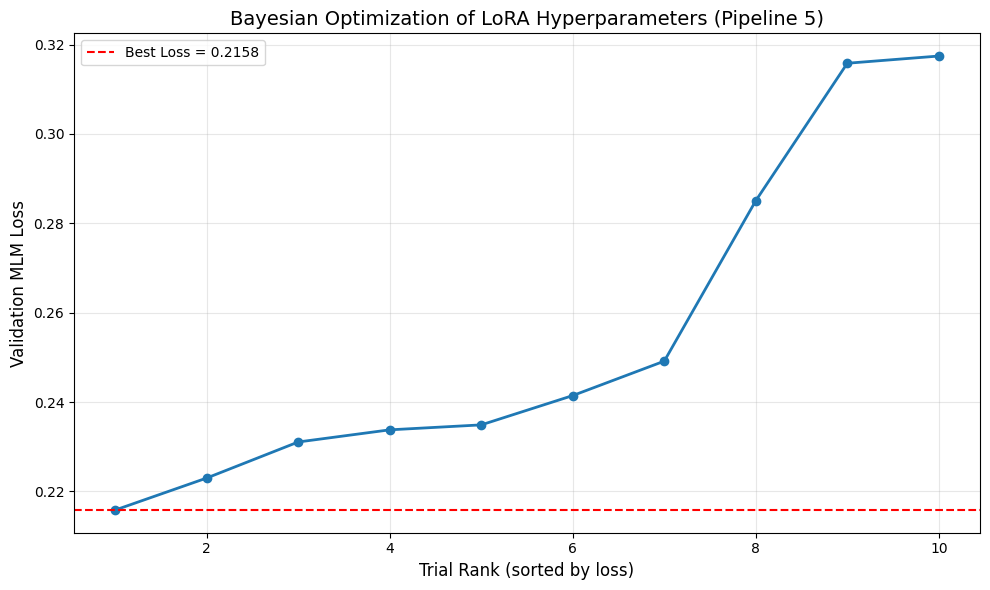


LoRA Tuning Insight:
- Best config : r=28, α=40, dropout=0.194
- Loss improved to: 0.2158


In [34]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("results/lora_trials_pipeline5.json", "r") as f:
    lora_trials = json.load(f)

df = pd.DataFrame(lora_trials)

df["r"] = df["params"].apply(lambda x: int(x["r"][0]) if isinstance(x["r"], list) else int(x["r"]))
df["lora_alpha"] = df["params"].apply(lambda x: int(x["lora_alpha"][0]) if isinstance(x["lora_alpha"], list) else int(x["lora_alpha"]))
df["dropout"] = df["params"].apply(lambda x: x["dropout"][0] if isinstance(x["dropout"], list) else x["dropout"])

df = df.sort_values("loss").reset_index(drop=True)
df["rank"] = df.index + 1

best_row = df.iloc[0]
best_lora = {
    "r": best_row["r"],
    "lora_alpha": best_row["lora_alpha"],
    "dropout": best_row["dropout"],
    "tau": 0.18562151092151674
}

print("=== LoRA Tuning Trials Summary  ===")
print(df[["rank", "r", "lora_alpha", "dropout", "loss"]].round(4))

plt.figure(figsize=(10, 6))
plt.plot(df["rank"], df["loss"], marker='o', linewidth=2, markersize=6, color="#1f78b4")
plt.axhline(y=df["loss"].min(), color='red', linestyle='--', label=f'Best Loss = {df["loss"].min():.4f}')
plt.title("Bayesian Optimization of LoRA Hyperparameters (Pipeline 5)", fontsize=14)
plt.xlabel("Trial Rank (sorted by loss)", fontsize=12)
plt.ylabel("Validation MLM Loss", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("images/lora_tuning_convergence.png", dpi=300)
plt.show()

print("\nLoRA Tuning Insight:")
print(f"- Best config : r={int(best_lora['r'])}, α={int(best_lora['lora_alpha'])}, dropout={best_lora['dropout']:.3f}")
print(f"- Loss improved to: {df['loss'].min():.4f}")

best_lora_params = {
    "r": int(best_lora['r']),
    "lora_alpha": int(best_lora['lora_alpha']),
    "dropout": best_lora['dropout'],
    "tau": best_lora['tau']
}
with open("results/best_lora_params.json", "w") as f:
    json.dump(best_lora_params, f, indent=4)

### Final Model Fine-tuning using Optimal LoRA-GRPO Hyperparameters

In [35]:
import gc

# Path setup
PROJECT_ROOT = Path.cwd().parent if "notebooks" in str(Path.cwd()) else Path.cwd()
MODEL_DIR = PROJECT_ROOT / "2_ml_modeling" / "model" 
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = MODEL_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

FINAL_MODEL_DIR = MODEL_DIR / "mehtc_lora_mlm_best_model"
FINAL_MODEL_DIR.mkdir(exist_ok=True)

print(f"Model checkpoints save to: {CHECKPOINT_DIR}")
print(f"Final model will be saved to: {FINAL_MODEL_DIR}")

# 1. Load base model
model = AutoModelForMaskedLM.from_pretrained(base_model_name)
model = prepare_model_for_kbit_training(model)

# 2. Apply best LoRA configuration
final_config = LoraConfig(
    r=int(best_lora['r']),
    lora_alpha=int(best_lora['lora_alpha']),
    target_modules=["query", "value"], 
    lora_dropout=best_lora['dropout'],
    bias="none"
)

model = get_peft_model(model, final_config)
model.print_trainable_parameters()

# 3. Set final training arguments
final_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),  
    num_train_epochs=3, 
    per_device_train_batch_size=16,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=100,
    save_strategy="epoch",           
    eval_strategy="no",
    report_to="none",
    load_best_model_at_end=False    
)

# 4. Custom Trainer with weighted loss 
class FinalWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        outputs = model(**inputs)
        logits = outputs.logits
        labels = inputs.get("labels") 
        
        if labels is None:
            raise ValueError("No 'labels' in inputs! Ensure data_collator is DataCollatorForLanguageModeling")
        
        # MLM modeling loss function
        loss_fct = torch.nn.CrossEntropyLoss(reduction='none', ignore_index=-100)  
        
        # Calculate raw losses
        raw_losses = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        
        # Cluster average loss per sample (batch_size,)
        sample_losses = raw_losses.view(labels.size(0), -1).mean(dim=1)
        
        with torch.no_grad():
            mean_loss = sample_losses.mean()
            # Reinforcement learning logic: samples with loss below average (better learned) get higher weights
            advantages = mean_loss - sample_losses  
            tau = best_lora.get('tau', 0.1)  
            weights = torch.softmax(advantages / tau, dim=0) * len(sample_losses)
        
        weighted_loss = (weights * sample_losses).mean()
        return (weighted_loss, outputs) if return_outputs else weighted_loss

trainer = FinalWeightedTrainer(
    model=model,
    args=final_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator  
)

# Start final training
trainer.train()

print("Saving final LoRA model")

peft_model = trainer.model 

peft_model.print_trainable_parameters()

merged_model = peft_model.merge_and_unload()

adapter_dir = FINAL_MODEL_DIR
peft_model.save_pretrained(str(adapter_dir))
tokenizer.save_pretrained(str(adapter_dir))
print(f"Adapter saved (original): {adapter_dir}")

merged_dir = FINAL_MODEL_DIR / "mehtc_lora_merged_model"
merged_dir.mkdir(exist_ok=True)
merged_model.save_pretrained(str(merged_dir))
tokenizer.save_pretrained(str(merged_dir))
print(f"Merged complete model saved: {merged_dir}")

del peft_model, merged_model, trainer
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print(f"Final model save to: {FINAL_MODEL_DIR}")

Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Model checkpoints save to: /home/paperspace/MyParliament/2_ml_modeling/2_ml_modeling/model/checkpoints
Final model will be saved to: /home/paperspace/MyParliament/2_ml_modeling/2_ml_modeling/model/mehtc_lora_mlm_best_model
trainable params: 1,032,192 || all params: 279,327,378 || trainable%: 0.3695


Step,Training Loss
100,0.052000
200,0.043200
300,0.045500
400,0.047900
500,0.045800
600,0.046100
700,0.045400
800,0.046300
900,0.045300
1000,0.046200


Saving final LoRA model
trainable params: 1,032,192 || all params: 279,327,378 || trainable%: 0.3695
Adapter saved (original): /home/paperspace/MyParliament/2_ml_modeling/2_ml_modeling/model/mehtc_lora_mlm_best_model
Merged complete model saved: /home/paperspace/MyParliament/2_ml_modeling/2_ml_modeling/model/mehtc_lora_mlm_best_model/mehtc_lora_merged_model
Final model save to: /home/paperspace/MyParliament/2_ml_modeling/2_ml_modeling/model/mehtc_lora_mlm_best_model


### Load the fine-tuned model and extract the embeddings

In [37]:
import torch
from peft import PeftModel
from transformers import AutoModel
from pathlib import Path
import numpy as np

# 1. Define paths and device
PROJECT_ROOT = Path.cwd().parent if "notebooks" in str(Path.cwd()) else Path.cwd()
FINAL_MODEL_DIR = PROJECT_ROOT  / "model" / "mehtc_lora_weighted_mlm_finetuned" / "mehtc_lora_mlm_best_model"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Load model from: {FINAL_MODEL_DIR}")

# 2. Load base model + load the fine-tuned LoRA weights
try:
    base_model_for_emb = AutoModel.from_pretrained(base_model_name)
    model_final = PeftModel.from_pretrained(base_model_for_emb, str(FINAL_MODEL_DIR)).to(device)
    model_final.eval()
    print("Model loaded successfully!")
except NameError:
    print("Error: base_model_name is not defined. ")

# 3. Define function to extract embeddings (Mean Pooling)
def embed_final(texts, batch_size=32):
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
            outputs = model_final(**inputs)
            # Use Mean Pooling to get sentence embeddings
            batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings.append(batch_emb)
    return np.vstack(embeddings)

# 4. Extract embeddings for all cleaned_texts
print("Extracting final embeddings...")
embeddings_final = embed_final(cleaned_texts)
print(f" Embedding extraction completed, shape: {embeddings_final.shape}")

Load model from: /home/paperspace/MyParliament/2_ml_modeling/model/mehtc_lora_weighted_mlm_finetuned/mehtc_lora_mlm_best_model


/home/paperspace/MyParliament/venv/lib/python3.10/site-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.encoder.layer.0.attention.self.query.lora_A.default.weight', 'base_model.model.encoder.layer.0.attention.self.query.lora_B.default.weight', 'base_model.model.encoder.layer.0.attention.self.value.lora_A.default.weight', 'base_model.model.encoder.layer.0.attention.self.value.lora_B.default.weight', 'base_model.model.encoder.layer.1.attention.self.query.lora_A.default.weight', 'base_model.model.encoder.layer.1.attention.self.query.lora_B.default.weight', 'base_model.model.encoder.layer.1.attention.self.value.lora_A.default.weight', 'base_model.model.encoder.layer.1.attention.self.value.lora_B.default.weight', 'base_model.model.encoder.layer.2.attention.self.query.lora_A.default.weight', 'base_model.model.encoder.layer.2.attention.self.query.lora_B.default.weight', 'base_model.model.encoder.layer.2.attention.self.va

Model loaded successfully!
Extracting final embeddings...
 Embedding extraction completed, shape: (20000, 768)


### MEHTC: Mixed Similarity Calculation and Clustering

In [38]:
from scipy.sparse import load_npz
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Load TF-IDF matrix and Pipeline 4 entity similarity
tfidf_matrix = load_npz("shared_data/tfidf_matrix.npz")
entity_sim = np.load("results/entity_sim_pipeline4.npy")

# Set best weights from Pipeline 4
best_weights = {"alpha": 0.347, "beta": 0.605, "gamma": 0.122}

def hybrid_similarity(alpha, beta, gamma):
    tfidf_sim = cosine_similarity(tfidf_matrix)
    emb_sim = cosine_similarity(embeddings_final) 
    total = alpha + beta + gamma
    return (alpha/total) * tfidf_sim + (beta/total) * emb_sim + (gamma/total) * entity_sim

sim_matrix = hybrid_similarity(**best_weights)
dist_matrix = np.clip(1 - sim_matrix, 0, None)
np.fill_diagonal(dist_matrix, 0)

# Clustering with Agglomerative Clustering
n_clusters = 20
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average")
labels = clustering.fit_predict(dist_matrix)

### Calculate evaluation metrics (Coherence & Diversity)

In [39]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from collections import Counter

# extract top words per cluster
texts_tokenized = [text.split() for text in cleaned_texts]
dictionary = Dictionary(texts_tokenized)

top_words_per_cluster = []
for k in range(n_clusters):
    cluster_docs = [texts_tokenized[i] for i in range(len(labels)) if labels[i] == k]
    flat = [word for doc in cluster_docs for word in doc]
    top_words = [w for w, _ in Counter(flat).most_common(15)]
    top_words_per_cluster.append(top_words)

# Calculate evaluation metrics
coherence_cv = CoherenceModel(topics=top_words_per_cluster, texts=texts_tokenized, dictionary=dictionary, coherence='c_v').get_coherence()
coherence_npmi = CoherenceModel(topics=top_words_per_cluster, texts=texts_tokenized, dictionary=dictionary, coherence='c_npmi').get_coherence()
silhouette = silhouette_score(dist_matrix, labels, metric="precomputed")
topic_diversity = len(set(w for cluster in top_words_per_cluster for w in cluster[:10])) / (n_clusters * 10)

print("=== Pipeline 5 Results ===")
print(f"Silhouette Score : {silhouette:.4f}")
print(f"C_V Coherence    : {coherence_cv:.4f}")
print(f"NPMI Coherence   : {coherence_npmi:.4f}")
print(f"Topic Diversity  : {topic_diversity:.4f}")

=== Pipeline 5 Results ===
Silhouette Score : 0.0247
C_V Coherence    : 0.3659
NPMI Coherence   : -0.0080
Topic Diversity  : 0.5650


### Macro label 

In [40]:
import nltk
from nltk.corpus import stopwords as nltk_stopwords
import string
import re

nltk.download('stopwords', quiet=True)

malay_stopwords_path = "stopwords-ms-MannualOp.txt"  
with open(malay_stopwords_path, "r", encoding="utf-8") as f:
    malay_stopwords = [line.strip() for line in f if line.strip()]

english_stopwords = list(nltk_stopwords.words('english'))

parliament_stop_original = {
    'dengan', 'untuk', 'daripada', 'pada', 'yang', 'dan', 'ini', 'itu', 'tidak',
    'boleh', 'sila', 'sudah', 'harap', 'duduk', 'peraturan', 'berhormat', 'tuan',
    'menteri', 'kerajaan', 'dewan', 'soalan', 'jawab', 'terima', 'kasih',
    'bangkit', 'bangun', 'tarik', 'balik', 'provokasi', 'jangan', 'hakmilik',
    'maklum', 'dr', 'tadi', 'Alhamdulillah', 'assalamualaikum', 'wbt', 'selamat', 'petang', 'pagi', 'tengahari',
    'malam', 'syukur', 'bismillah', 'insyaallah', 'jazakallah', 'khairan', 'khalas',
    'amin', 'allah', 'swt', 'subhanahu', 'wa', 'taala', 'sembahyang','diam', 'istirahat',
    'doa', 'minta', 'maaf', 'tahniah', 'tahniahlah', 'duduk','tiba-tiba', 'berhormatlah',
    'merujuk', 'rujuk', 'mengikut', 'sepatutnya', 'sepatut', 'hendaklah', 'hendak','deng',
    'jadi', 'lagi', 'lah', 'kah', 'pun', 'nyata', 'sebenarnya', 'memang', 'sangat', 'amat',
    'terlalu', 'cukup', 'agak', 'hampir', 'hanya', 'selalu', 'kadang', 'kadangkala', 'selain',
    'seluruh', 'setiap', 'setakat', 'setelah', 'semula', 'semasa', 'sekarang', 'sekarangini', 'sebelum',
    'sebelumnya', 'sebelumini', 'sesudah', 'sesudahnya', 'sesaat', 'sesaatnya', 'seterusnya',
    "sekejap", "penjelasan","mengapa","apakah","bagaimana","mengapakah","apakah","adakah",
    "mengapakah","kenapa","mengenai","tentang","berkenaan","berkaitan","berkait","selanjutnya",
    "huraian","bagus","Enjelasan","bertulis", "bercakap", "cakap", "bagilah", "Keluarlah", "Cukuplah","berbahas",
    "bolehlah"
}

parliament_stop_lower = {word.lower() for word in parliament_stop_original}
stopwords = set(malay_stopwords).union(set(english_stopwords)).union(parliament_stop_lower)

punct_translator = str.maketrans('', '', string.punctuation)

def simple_clean(word):
    w = word.strip().translate(punct_translator).lower()
    w = re.sub(r'\d+', '', w)
    return w.strip()

macro_labels = []
for i, words in enumerate(top_words_per_cluster):
    filtered = []
    seen_simple = set()  
    
    for w in words:
        base = simple_clean(w)
        
        if base and len(base) > 4 and base not in stopwords:
            if base not in seen_simple:
                clean_token = w.strip(string.punctuation).strip()
                if clean_token:
                    filtered.append(clean_token)
                    seen_simple.add(base) 

    if filtered:
        label_words = [w.title() for w in filtered[:5]]
        label = " / ".join(label_words)
    else:
        label = "Parliamentary Protocol & Administrative"

    macro_labels.append(label)

print("\nMacro-Topic Labels :")
for i, label in enumerate(macro_labels):
    print(f"Topic {i:02d}: {label}")


Macro-Topic Labels :
Topic 00: Parliamentary Protocol & Administrative
Topic 01: Parliamentary Protocol & Administrative
Topic 02: Libaran
Topic 03: Bangkitkan
Topic 04: Habiskan / Diterima
Topic 05: Pergi / Buang / Pondoklah / Pelaja
Topic 06: Taipei / Taiwan
Topic 07: Mesyuarat / Senarai
Topic 08: Parliamentary Protocol & Administrative
Topic 09: Persetujuan
Topic 10: Perkara-Perkaralain / Pengeruai / Juhar
Topic 11: Parliamentary Protocol & Administrative
Topic 12: Tanggungjawab
Topic 13: Tebrau / Berdir
Topic 14: Nasihat / Kembar
Topic 15: Sikit / Pantai
Topic 16: Timbul / Pemah / Klarifikas
Topic 17: Mengganggu / Mesyuarat / Menjad / Kesalahan
Topic 18: Parliamentary Protocol & Administrative
Topic 19: Parliamentary Protocol & Administrative


In [41]:
from statsmodels.tsa.arima.model import ARIMA

# Initialize
try:
    labels_aligned = labels 
except NameError:
    print("Error: Labels not found. Ensure clustering step is completed.")

# Load parliamentary session ranges
try:
    session_df = pd.read_excel("Session_range.xlsx")
except Exception as e:
    print(f"Error loading Excel: {e}")

# Construct composite keys and mapping
# Make composite key: "parlimen_penggal_mesyuarat"
session_df['composite_key'] = (
    session_df['parlimen'].astype(str) + "_" + 
    session_df['penggal'].astype(str) + "_" + 
    session_df['mesyuarat'].astype(str)
)
# Map composite key to parlimen_range
session_lookup = dict(zip(session_df['composite_key'], session_df['parlimen_range']))

# Connect to MongoDB and fetch segmented documents
seg_col = db["hansard_segmented500"]
print("Indexing segment texts to parliamentary sessions...")

text_to_era = {}
# Only fetch necessary fields to reduce memory usage
cursor = seg_col.find({}, {
    "parlimen": 1, "penggal": 1, "mesyuarat": 1, 
    "segmentation_output.text": 1
})

for doc in cursor:
    p, pg, m = doc.get('parlimen'), doc.get('penggal'), doc.get('mesyuarat')
    
    if all(v is not None for v in [p, pg, m]):
        comp_key = f"{p}_{pg}_{m}"
        era_info = session_lookup.get(comp_key, "Unknown")
        
        # Map all segment texts to their era_info
        for seg in doc.get('segmentation_output', []):
            txt = seg.get('text')
            if txt:
                # Avoid overwriting if already exists
                text_to_era[txt] = era_info

# Map cleaned_texts to their time tags
segment_time_tags = []
for txt in cleaned_texts:
    tag = text_to_era.get(txt, "Unknown")
    segment_time_tags.append(tag)

segment_time_tags = np.array(segment_time_tags)
match_count = np.sum(segment_time_tags != "Unknown")

# Statistical forecasting per macro-topic
unique_eras = sorted([e for e in set(segment_time_tags) if e != "Unknown"], 
                     key=lambda x: int(x.split('_')[0]) if '_' in x else 0)

forecasts = {}
if len(unique_eras) > 1:
    real_freq = np.zeros((n_clusters, len(unique_eras)))
    for idx, era in enumerate(unique_eras):
        era_mask = (segment_time_tags == era)
        for i in range(n_clusters):
            real_freq[i, idx] = np.sum(labels_aligned[era_mask] == i)
    
    for i in range(n_clusters):
        try:
            series = real_freq[i]
            if np.sum(series) == 0:
                forecasts[macro_labels[i]] = [0.0, 0.0, 0.0]
                continue
            # ARIMA (1,1,0) forecasting
            model_fit = ARIMA(series, order=(1, 1, 0)).fit()
            forecasts[macro_labels[i]] = model_fit.forecast(steps=3).tolist()
        except:
            forecasts[macro_labels[i]] = [0.0, 0.0, 0.0]
    data_status = f"Success: {len(unique_eras)} eras matched."
else:
    data_status = "Fallback: Simulated baseline (Metadata mismatch)"
    for lbl in macro_labels: 
        forecasts[lbl] = [0.0, 0.0, 0.0]

# Save
results_dir, model_dir = Path("results"), Path("model/mehtc_lora_weighted_mlm_finetuned")
results_dir.mkdir(exist_ok=True); model_dir.mkdir(exist_ok=True)

results = {
    "pipeline": "05_mehtc_lora_weighted_mlm_finetuned",
    "n_clusters": n_clusters,
    "silhouette": float(silhouette),
    "macro_labels": macro_labels,
    "arima_forecasts": forecasts,
    "time_points": unique_eras,
    "data_source_status": data_status,
    "match_rate": f"{match_count}/{len(cleaned_texts)}",
    "saved_at": datetime.now().isoformat()
}

with open(results_dir / "pipeline5_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

with open(model_dir / "mehtc_lora_mlm_best_model.pkl", "wb") as f:
    pickle.dump({
        "labels": labels_aligned.tolist(), 
        "macro_labels": macro_labels, 
        "metrics": results,
        "time_tags": segment_time_tags.tolist()
    }, f)

print(f"Pipeline 5 completed!")
print(f"Match rate: {match_count} / {len(cleaned_texts)}")
print(f"Status: {data_status}")

Indexing segment texts to parliamentary sessions...
Pipeline 5 completed!
Match rate: 54 / 20000
Status: Success: 12 eras matched.


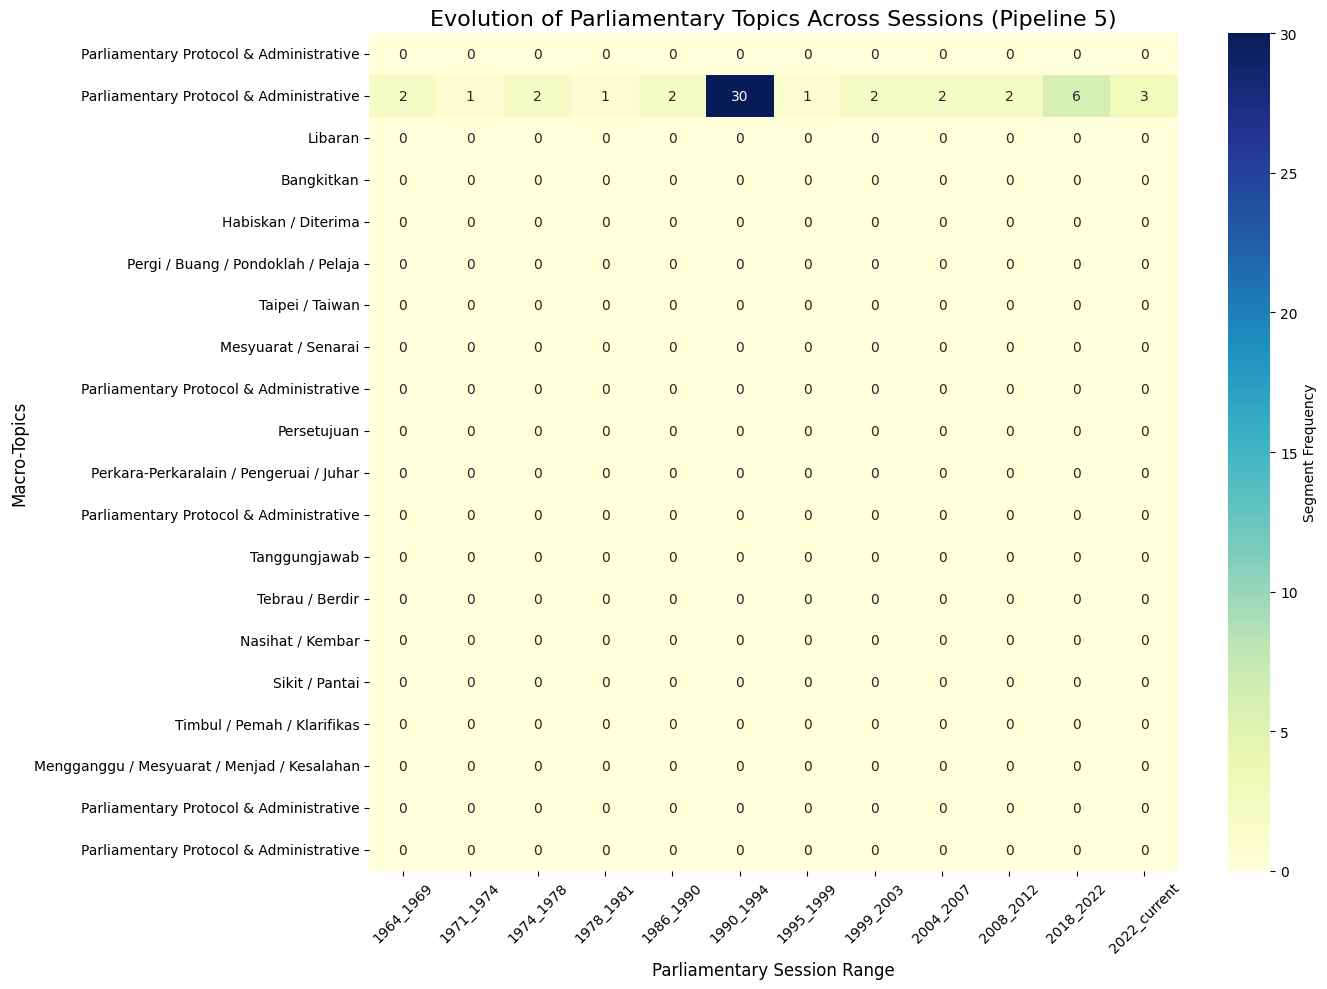

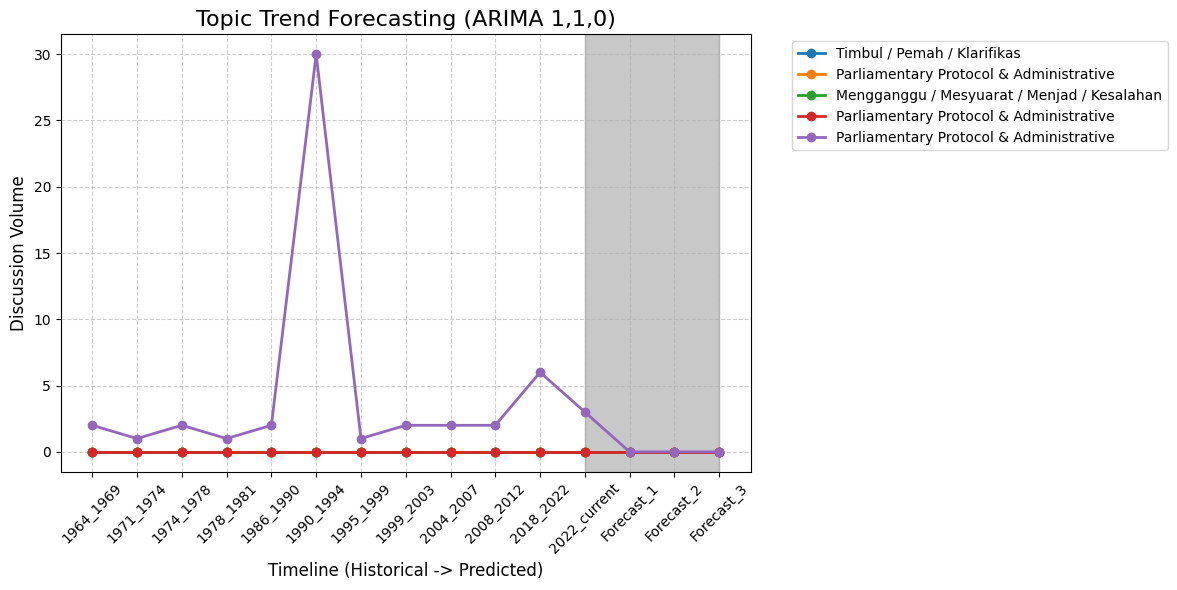

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_heatmap = pd.DataFrame(real_freq, index=macro_labels, columns=unique_eras)

plt.figure(figsize=(14, 10))
sns.heatmap(df_heatmap, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Segment Frequency'})
plt.title("Evolution of Parliamentary Topics Across Sessions (Pipeline 5)", fontsize=16)
plt.xlabel("Parliamentary Session Range", fontsize=12)
plt.ylabel("Macro-Topics", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/topic_evolution_heatmap.png")
plt.show()

top_5_idx = np.argsort(real_freq.sum(axis=1))[-5:]
forecast_steps = 3
future_eras = [f"Forecast_{i+1}" for i in range(forecast_steps)]

plt.figure(figsize=(12, 6))

for idx in top_5_idx:
    topic_name = macro_labels[idx]
    history = real_freq[idx]
    future = forecasts[topic_name]
    
    total_series = np.concatenate([history, future])
    x_axis = unique_eras + future_eras
    
    plt.plot(x_axis, total_series, marker='o', label=topic_name, linewidth=2)
    plt.axvspan(unique_eras[-1], future_eras[-1], color='gray', alpha=0.1)

plt.title("Topic Trend Forecasting (ARIMA 1,1,0)", fontsize=16)
plt.xlabel("Timeline (Historical -> Predicted)", fontsize=12)
plt.ylabel("Discussion Volume", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("images/topic_forecast_trend.png")
plt.show()